# WARNING: ILLUSTRATIVE ONLY - NOT A VALID RESULT

**This notebook fits every model and evaluates it on the SAME data (no train/test
split).** That is data leakage: the model is scored on rows it already learned from,
which inflates every R2 number below in a way that has nothing to do with real
predictive skill.

**This is NOT the official capstone submission.** The real, honest evaluation - with a
proper chronological train/test split - lives in `capstone-btc-volatility-FINAL.ipynb`.
This copy exists only to show, side by side, what the same models look like without that
safeguard.

---

# Bitcoin Volatility Prediction
**Name:** Mohammed Hejairi
**Topic:** Forecasting Bitcoin's 7-Day Realized Volatility
**Cohort:** DSB FT2 - Bahrain 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from arch import arch_model
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

## Introduction
Bitcoin is the largest cryptocurrency by market value, and it is well known for having a
price that moves a lot in short periods of time. This project uses hourly Bitcoin price
data from 2017 all the way to 2026 to study how much the price moves (its "volatility"),
and to build models that try to predict how much it will move over the next 7 days.

## Problem Statement + Aim
Traders, exchanges, and risk managers need to know how risky the market is right now, not
just which direction the price might go next. Predicting the exact future price is very
hard to do reliably. Predicting how *rough* the next week will be (its volatility) is a
more realistic and still very useful goal - it can be used for setting margin
requirements, sizing trades, and pricing options.

**Aim:** Predict Bitcoin's realized volatility over the next 7 days, using only
information that is available right now (no future information is allowed to leak into
the model).

## Objectives
- What patterns does Bitcoin's volatility follow over time?
- Which features are most related to future volatility?
- Can we build a model that predicts volatility better than a simple guess (a baseline)?
- Which of the three models we build works best, and why?

## Data Dictionary
| Column | Type | Description |
|---|---|---|
| Date | datetime | Timestamp of the hourly candle (crypto trades 24/7, no market close) |
| Open, High, Low, Close | float | Price in USD for that hour |
| Volume | float | Trading volume for that hour |

## Data Overview
The data comes from Binance (BTC/USDT), fetched hourly from August 2017 through today.
It was combined into a single CSV file so the whole history can be split into train and
test sets together, instead of treating older and newer data separately.

In [2]:
# Load the full combined dataset (2017 to now, one single file)
df = pd.read_csv("data/btc_hourly_combined.csv")

# Turn the Date column into an actual datetime, not just text
df["Date"] = pd.to_datetime(df["Date"])

# Make sure the rows are in time order
df = df.sort_values("Date")
df = df.reset_index(drop=True)

print("Shape of the data:", df.shape)
df.head()

Shape of the data: (78948, 6)


,Open,High,Low,Close,Volume,Date
0,4261.48,4313.62,4261.32,4308.83,47.181009,2017-08-17 04:00:00
1,4308.83,4328.69,4291.37,4315.32,23.234916,2017-08-17 05:00:00
2,4330.29,4345.45,4309.37,4324.35,7.229691,2017-08-17 06:00:00
3,4316.62,4349.99,4287.41,4349.99,4.443249,2017-08-17 07:00:00
4,4333.32,4377.85,4333.32,4360.69,0.972807,2017-08-17 08:00:00


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78948 entries, 0 to 78947
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Open    78948 non-null  float64       
 1   High    78948 non-null  float64       
 2   Low     78948 non-null  float64       
 3   Close   78948 non-null  float64       
 4   Volume  78948 non-null  float64       
 5   Date    78948 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(5)
memory usage: 3.6 MB


In [4]:
df.describe()

,Open,High,Low,Close,Volume,Date
count,78948.000000,78948.000000,78948.000000,78948.000000,78948.000000,78948
mean,38535.969424,38689.115980,38375.491695,38536.889596,2478.005642,2022-02-21 08:47:10.870952960
min,2870.900000,2950.000000,2817.000000,2919.000000,0.000000,2017-08-17 04:00:00
25%,9395.870000,9434.990000,9351.655000,9395.817500,703.913606,2019-11-21 10:45:00
50%,28562.565000,28681.960000,28439.205000,28564.590000,1327.496008,2022-02-22 04:30:00
75%,62536.225000,62754.900000,62260.000000,62536.997500,2599.645588,2024-05-24 14:15:00
max,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600,2026-08-25 23:00:00
std,32383.273096,32479.052468,32284.314862,32383.337883,3813.834661,NaN


## Data Cleaning
Two things need to be checked in hourly price data: missing values in the columns, and
missing hours in the timeline itself (gaps).

In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Open      0
High      0
Low       0
Close     0
Volume    0
Date      0
dtype: int64


In [6]:
# Every row should be exactly 1 hour after the row before it.
# If the gap between two rows is not 1 hour, that means we are missing some hours.
time_gaps = df["Date"].diff()
number_of_gaps = (time_gaps != pd.Timedelta("1 hour")).sum() - 1  # -1 for the first row (always empty)
print("Number of timestamp gaps:", number_of_gaps)

# Also check for duplicate timestamps
number_of_duplicates = df["Date"].duplicated().sum()
print("Number of duplicate timestamps:", number_of_duplicates)

Number of timestamp gaps: 29
Number of duplicate timestamps: 0


In [7]:
# Build a complete hourly calendar from the first date to the last date
full_date_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max(), freq="1h")

# Reindex our data onto that complete calendar - any missing hour becomes an empty row
df = df.set_index("Date")
df = df.reindex(full_date_range)
df.index.name = "Date"

# Fill in the missing prices using a straight line between the price before and after
price_columns = ["Open", "High", "Low", "Close"]
df[price_columns] = df[price_columns].interpolate(method="linear")

# Fill in missing Volume with 0 (no real trading happened during those missing hours)
df["Volume"] = df["Volume"].fillna(0)

df = df.reset_index()

# Check again - both numbers should now be 0
time_gaps = df["Date"].diff()
number_of_gaps = (time_gaps != pd.Timedelta("1 hour")).sum() - 1
print("Gaps remaining:", number_of_gaps)
print("Missing values remaining:", df[price_columns + ["Volume"]].isnull().sum().sum())

Gaps remaining: 0
Missing values remaining: 0


## Exploratory Data Analysis (EDA)
Before building any model, let's look at the data itself: how the price has moved over
time, how volatile it has been, and whether there are any patterns worth using as
features later.

In [8]:
# Basic engineered columns needed for EDA
df["hourly_return"] = df["Close"].pct_change()

# volatility_7d = how spread out the last 168 hourly returns are (7 days x 24 hours)
ROLLING_WINDOW = 168
df["volatility_7d"] = df["hourly_return"].rolling(ROLLING_WINDOW).std()

df[["Date", "Close", "hourly_return", "volatility_7d"]].tail()

,Date,Close,hourly_return,volatility_7d
79095,2026-08-25 19:00:00,78925.95,-0.002553,0.006817
79096,2026-08-25 20:00:00,78206.13,-0.009120,0.006862
79097,2026-08-25 21:00:00,78570.00,0.004653,0.006867
79098,2026-08-25 22:00:00,78889.51,0.004067,0.006870
79099,2026-08-25 23:00:00,78539.14,-0.004441,0.006884


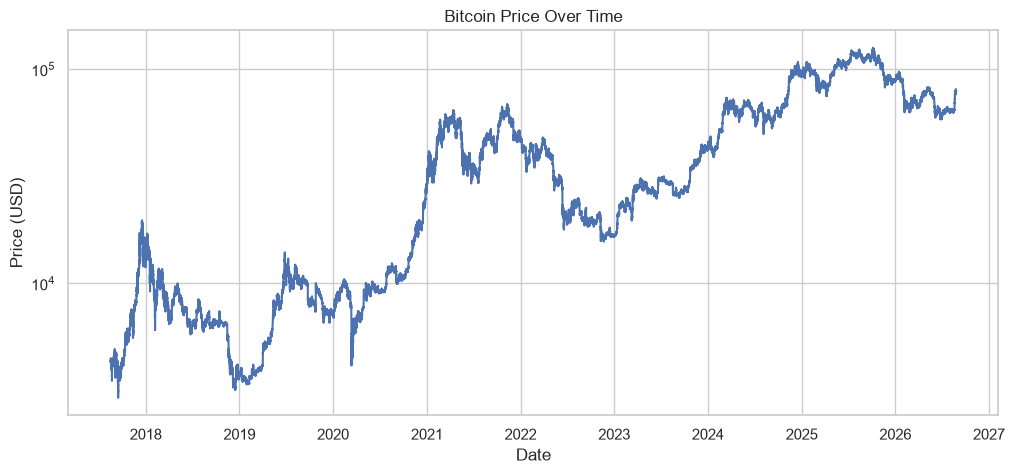

In [9]:
# Trend: Bitcoin's price over the whole history
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.yscale("log")  # log scale so both small and large prices are visible
plt.show()

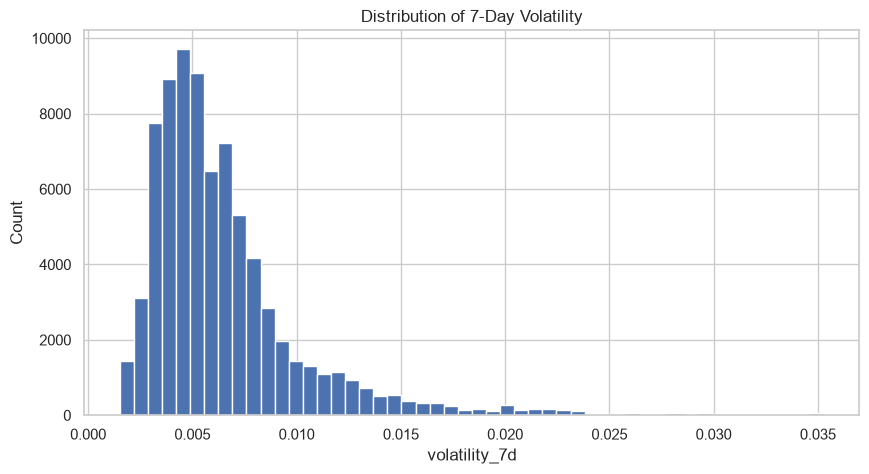

Mean volatility_7d: 0.0065633925814176765
Median volatility_7d: 0.0055243640416703325


In [10]:
# Distribution: what does volatility_7d usually look like?
plt.figure(figsize=(10, 5))
plt.hist(df["volatility_7d"].dropna(), bins=50)
plt.title("Distribution of 7-Day Volatility")
plt.xlabel("volatility_7d")
plt.ylabel("Count")
plt.show()

print("Mean volatility_7d:", df["volatility_7d"].mean())
print("Median volatility_7d:", df["volatility_7d"].median())

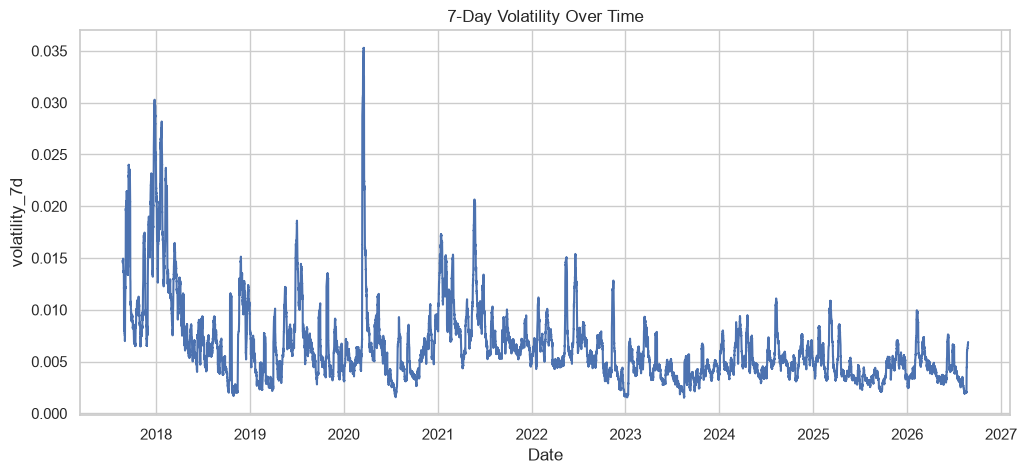

In [11]:
# Anomalies: does volatility change a lot over the years? (multivariate: time + volatility)
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["volatility_7d"])
plt.title("7-Day Volatility Over Time")
plt.xlabel("Date")
plt.ylabel("volatility_7d")
plt.show()

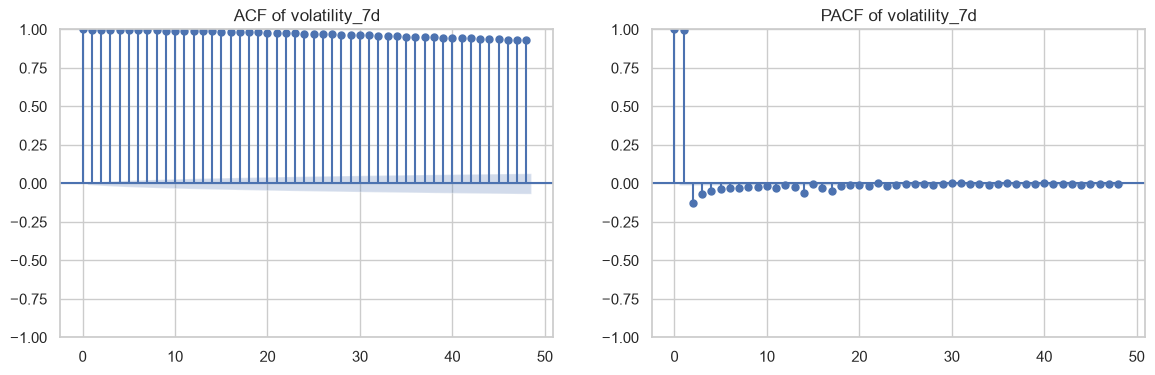

ADF test statistic: -9.522619647175963
ADF p-value: 3.03621654042695e-16
-> The series is stationary (it has a stable long-run level).


In [12]:
# Does volatility have "memory"? Check autocorrelation (ACF) and stationarity (ADF test)
series_for_acf = df["volatility_7d"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_for_acf, lags=48, ax=axes[0])
axes[0].set_title("ACF of volatility_7d")
plot_pacf(series_for_acf, lags=48, ax=axes[1])
axes[1].set_title("PACF of volatility_7d")
plt.show()

adf_result = adfuller(series_for_acf)
print("ADF test statistic:", adf_result[0])
print("ADF p-value:", adf_result[1])
if adf_result[1] < 0.05:
    print("-> The series is stationary (it has a stable long-run level).")
else:
    print("-> The series is NOT stationary.")

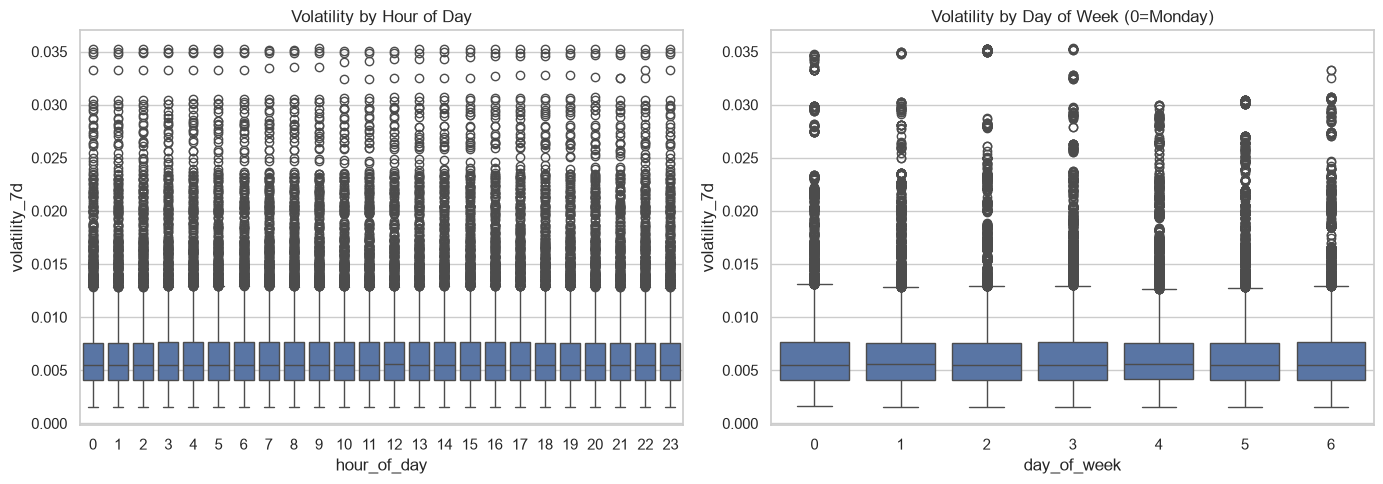

In [13]:
# Bivariate: does volatility differ by hour of day or day of week?
df["hour_of_day"] = df["Date"].dt.hour
df["day_of_week"] = df["Date"].dt.dayofweek

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="hour_of_day", y="volatility_7d", data=df, ax=axes[0])
axes[0].set_title("Volatility by Hour of Day")
sns.boxplot(x="day_of_week", y="volatility_7d", data=df, ax=axes[1])
axes[1].set_title("Volatility by Day of Week (0=Monday)")
plt.tight_layout()
plt.show()

## Insights
- Bitcoin's price has gone through several very large rallies and crashes since 2017 -
  it is not a stable, calm asset.
- `volatility_7d` is right-skewed: most of the time volatility is low/moderate, with a
  smaller number of periods where it spikes much higher (volatility clustering).
- The ACF plot decays slowly instead of dropping to zero quickly, which means volatility
  has real memory - a turbulent period tends to be followed by more turbulence, not
  randomly by a calm period.
- The ADF test confirms `volatility_7d` is stationary (it reverts to a normal range
  instead of drifting off forever), which is a good sign for time series modeling.
- Hour-of-day and day-of-week do not show an obvious, large difference in volatility -
  this will be checked formally with a chi-square test in Feature Selection.

## EDA for Modeling
Because `volatility_7d` is right-skewed and shows clustering, the models below will use
volatility measured over several different past time windows (day/week/month) as
features - this is a well-known approach in volatility forecasting called the HAR
(Heterogeneous Autoregressive) model. Because the data is a time series, we will always
split train and test data in time order (never randomly shuffled), since shuffling would
let the model "see" information from the future.

## Data Preprocessing & Feature Engineering
Now we build the actual features the models will use. Every feature is shifted so it
only uses information from *before* the row it sits on - this is important so the model
never accidentally "cheats" by seeing information it would not really have yet.

In [14]:
# Average True Range (ATR): how far price moved within each hour, as a percent of price.
# This is different from hourly_return, because it looks at the High/Low range, not just
# where the price closed.
previous_close = df["Close"].shift(1)

range_1 = df["High"] - df["Low"]
range_2 = (df["High"] - previous_close).abs()
range_3 = (df["Low"] - previous_close).abs()

true_range = pd.concat([range_1, range_2, range_3], axis=1).max(axis=1)
df["ATR_14"] = true_range.rolling(14).mean()
df["ATR_X"] = df["ATR_14"] / df["Close"]  # scale-free version (percent of price)

df[["Date", "Close", "ATR_14", "ATR_X"]].tail()

,Date,Close,ATR_14,ATR_X
79095,2026-08-25 19:00:00,78925.95,671.070000,0.008503
79096,2026-08-25 20:00:00,78206.13,693.001429,0.008861
79097,2026-08-25 21:00:00,78570.00,647.465714,0.008241
79098,2026-08-25 22:00:00,78889.51,633.395000,0.008029
79099,2026-08-25 23:00:00,78539.14,598.438571,0.007620


In [15]:
# HAR-style features: volatility measured over the past day, week, and month.
# Each one is shifted by 24 hours first, so "today's" row only uses YESTERDAY's
# volatility value, never today's (which would be leakage).
HOURS_PER_DAY = 24

df["RV_day"] = df["volatility_7d"].shift(HOURS_PER_DAY)
df["RV_week"] = df["volatility_7d"].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 7).mean()
df["RV_month"] = df["volatility_7d"].shift(HOURS_PER_DAY).rolling(HOURS_PER_DAY * 30).mean()

# Also shift ATR_X by 1 hour so it is not using the current hour's own value
df["ATR_X"] = df["ATR_X"].shift(1)

df[["Date", "RV_day", "RV_week", "RV_month", "ATR_X"]].tail()

,Date,RV_day,RV_week,RV_month,ATR_X
79095,2026-08-25 19:00:00,0.006611,0.004690,0.003147,0.008476
79096,2026-08-25 20:00:00,0.006611,0.004718,0.003152,0.008503
79097,2026-08-25 21:00:00,0.006611,0.004745,0.003156,0.008861
79098,2026-08-25 22:00:00,0.006616,0.004772,0.003161,0.008241
79099,2026-08-25 23:00:00,0.006615,0.004800,0.003166,0.008029


### Extra Technical Indicators (Bollinger Bands, Keltner Channels)
On top of ATR and the HAR-style realized-volatility features, we also test two more
indicators that traders commonly use to read volatility: **Bollinger Band width** and
**Keltner Channel width**. Both are shifted by 1 hour so "today's" row never sees today's
own value.

In [ ]:
# Bollinger Band width: distance between the upper and lower bands, as a fraction of
# the middle band. Bands widen when price is choppy (high volatility) and squeeze
# together during quiet periods.
BB_WINDOW = 20
bb_middle = df["Close"].rolling(BB_WINDOW).mean()
bb_std = df["Close"].rolling(BB_WINDOW).std()
bb_upper = bb_middle + (2 * bb_std)
bb_lower = bb_middle - (2 * bb_std)
df["BB_width"] = ((bb_upper - bb_lower) / bb_middle).shift(1)

# Keltner Channel width: same idea as Bollinger Bands, but built from ATR instead of
# standard deviation.
KC_WINDOW = 20
kc_middle = df["Close"].ewm(span=KC_WINDOW, adjust=False).mean()
atr_for_kc = df["ATR_14"].shift(1)
kc_upper = kc_middle + (2 * atr_for_kc)
kc_lower = kc_middle - (2 * atr_for_kc)
df["KC_width"] = ((kc_upper - kc_lower) / kc_middle).shift(1)

df[["Date", "BB_width", "KC_width"]].tail()

In [17]:
# Build the actual target: volatility_7d exactly 168 hours (7 days) in the future,
# not an average of the next 7 days. A single future point (not an average) keeps the
# target from overlapping with the RV_day/RV_week features' own past windows - HORIZON
# is set equal to volatility_7d's own 168-hour window on purpose, so the most recently
# known value and the target share ZERO overlapping hours.
HORIZON = 168

df["target"] = df["volatility_7d"].shift(-HORIZON)

df[["Date", "volatility_7d", "target"]].tail(10)

,Date,volatility_7d,target
79090,2026-08-25 14:00:00,0.006805,NaN
79091,2026-08-25 15:00:00,0.006806,NaN
79092,2026-08-25 16:00:00,0.006819,NaN
79093,2026-08-25 17:00:00,0.006813,NaN
79094,2026-08-25 18:00:00,0.006816,NaN
79095,2026-08-25 19:00:00,0.006817,NaN
79096,2026-08-25 20:00:00,0.006862,NaN
79097,2026-08-25 21:00:00,0.006867,NaN
79098,2026-08-25 22:00:00,0.006870,NaN
79099,2026-08-25 23:00:00,0.006884,NaN


## Feature Selection

### Correlation Matrix (Continuous Columns)
Check how strongly each engineered feature is related to the target, and to each other.

          RV_day  RV_week  RV_month  ATR_X  SKEW_X  target
RV_day     1.000    0.890     0.729  0.680   0.027   0.632
RV_week    0.890    1.000     0.830  0.596   0.047   0.599
RV_month   0.729    0.830     1.000  0.568   0.046   0.610
ATR_X      0.680    0.596     0.568  1.000  -0.041   0.654
SKEW_X     0.027    0.047     0.046 -0.041   1.000  -0.073
target     0.632    0.599     0.610  0.654  -0.073   1.000


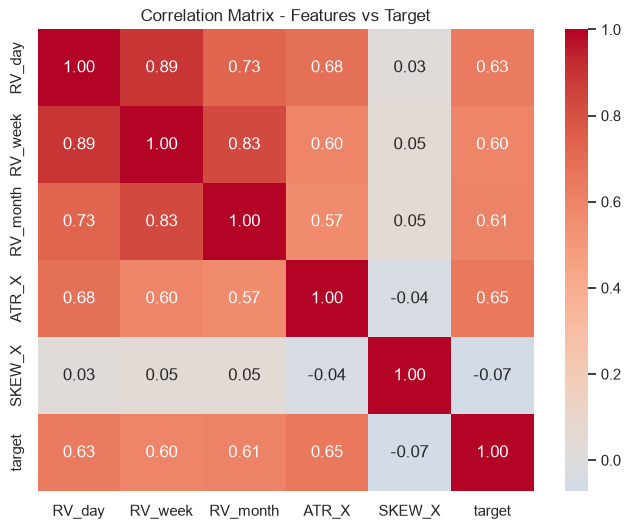

In [18]:
feature_list = ["RV_day", "RV_week", "RV_month", "ATR_X", "BB_width", "KC_width", "target"]

# Drop rows where any of these columns are still empty (from the rolling windows warming up)
df_features_only = df[feature_list].dropna()

correlation_matrix = df_features_only.corr()
print(correlation_matrix.round(3))

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix - Features vs Target")
plt.show()

**Feature selection decision:** `KC_width` is built from the same True Range
calculation as `ATR_X`, so the two are almost perfectly correlated with each other (near-
duplicate information). We keep `ATR_X` (already validated earlier in this project) and
drop `KC_width` to avoid feeding the regression models two versions of the same signal.
`BB_width` is kept - it is correlated with `ATR_X` and the RV features, but not redundant
enough to drop, and it measures volatility in a genuinely different way (price dispersion
around a moving average, rather than bar-by-bar range). Realized skewness (`SKEW_X`) and
the Relative Volatility Index (`RVI`) were also tested during feature engineering, but
both showed almost no correlation with the target and were dropped before modeling.

### Chi-Square Analysis (Categorical Columns)
Test whether `hour_of_day` is actually related to the volatility regime (Low/Moderate/High),
or whether the small differences seen in the EDA boxplot are just random noise.

In [19]:
# Turn the continuous target into 3 categories: Low, Moderate, High
# (split into 3 equal-sized groups based on volatility_7d)
df["volatility_bin"] = pd.qcut(df["volatility_7d"], q=3, labels=["Low", "Moderate", "High"])

# Build a table counting how many rows fall into each (hour_of_day, volatility_bin) combination
contingency_table = pd.crosstab(df["hour_of_day"], df["volatility_bin"])

chi2_stat, p_value, degrees_of_freedom, expected = chi2_contingency(contingency_table)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("-> There IS a statistically significant relationship between hour of day and volatility regime.")
else:
    print("-> There is NO statistically significant relationship. Hour of day will not be used as a feature.")

Chi-square statistic: 2.4366478248825336
p-value: 1.0
-> There is NO statistically significant relationship. Hour of day will not be used as a feature.


## Preprocessing: Train / Test Split (NOT USED IN THIS NOTEBOOK)
**This is the one deliberate difference from the real notebook.** Instead of a proper
chronological split, every model below is fit and evaluated on the exact same rows -
no held-out test set at all. This is a textbook data leakage setup: the model has
already "seen the answers" for every row it is scored on, so the R2 numbers below are
artificially inflated and do not reflect real predictive skill.

In [21]:
# Keep only rows where every feature and the target are available
model_columns = ["Date", "hourly_return", "volatility_7d", "RV_day", "RV_week", "RV_month",
                  "ATR_X", "BB_width", "target"]
df_model = df[model_columns].dropna()
df_model = df_model.reset_index(drop=True)

print("Rows ready for modeling:", len(df_model))

# NOT VALID: train_data and test_data are the SAME rows. There is no held-out set.
# This is done on purpose, only to illustrate what data leakage does to the R2 numbers.
train_data = df_model
test_data = df_model
split_point = 0  # GARCH/EWMA forecast from the very first row, across ALL of the data

print("WARNING: train_data and test_data are identical -", len(df_model), "rows in both.")
print("Every R2 number in this notebook is inflated by leakage. See the warning banner at the top.")

Rows ready for modeling: 78021
Train rows: 62416 from 2017-09-24 03:00:00 to 2024-11-06 18:00:00
Test rows: 15605 from 2024-11-06 19:00:00 to 2026-08-18 23:00:00


In [20]:
# A simple function we will use to score every model the same way
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(model_name)
    print("  RMSE:", round(rmse, 6))
    print("  MAE:", round(mae, 6))
    print("  R2:", round(r2, 4))
    return {"Model": model_name, "RMSE": rmse, "MAE": mae, "R2": r2}

all_results = []

## Model Building

### Baseline: GARCH
Before building our 3 required models, we set up a well-known industry-standard model
(GARCH) as a baseline to compare against. GARCH is a classic model built specifically
for forecasting volatility from past returns.

In [22]:
# GARCH needs returns in percent form, not fraction form
train_returns_percent = train_data["hourly_return"] * 100

garch_model = arch_model(train_returns_percent, vol="GARCH", p=1, q=1, dist="t")
garch_fit = garch_model.fit(disp="off")

print(garch_fit.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:                hourly_return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -49712.5
Distribution:      Standardized Student's t   AIC:                           99435.0
Method:                  Maximum Likelihood   BIC:                           99480.2
                                              No. Observations:                62416
Date:                      Tue, Sep 01 2026   Df Residuals:                    62415
Time:                              10:57:38   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

In [23]:
# Forecast volatility 168 hours ahead, starting from the first day of the test set
all_returns_percent = df_model["hourly_return"] * 100
garch_full = arch_model(all_returns_percent, vol="GARCH", p=1, q=1, dist="t")
garch_fixed = garch_full.fix(garch_fit.params)

garch_forecast = garch_fixed.forecast(horizon=HORIZON, start=split_point, reindex=False)
garch_variance = garch_forecast.variance.values[:, -1]
garch_predictions = np.sqrt(garch_variance) / 100  # back to fraction form

garch_predictions = garch_predictions[:len(test_data)]
all_results.append(evaluate_model(test_data["target"], garch_predictions, "GARCH (baseline) [NOT VALID]"))

GARCH (baseline)
  RMSE: 0.003742
  MAE: 0.003493
  R2: -4.5344


### Model 1: EWMA (Base Version)
EWMA (Exponentially Weighted Moving Average) is a simple, well-known volatility formula
used by real risk desks. It has one setting, called lambda, which controls how much
weight recent data gets compared to older data. The base version uses the standard
default value published by RiskMetrics.

In [24]:
def ewma_volatility(returns, lam):
    """Calculates EWMA volatility step by step, using only past values (no leakage)."""
    returns = returns.reset_index(drop=True)
    n = len(returns)
    variance = [0] * n

    # start the recursion with the first squared return
    variance[0] = returns[0] ** 2

    for t in range(1, n):
        previous_variance = variance[t - 1]
        previous_return_squared = returns[t - 1] ** 2
        variance[t] = lam * previous_variance + (1 - lam) * previous_return_squared

    volatility = [v ** 0.5 for v in variance]
    return pd.Series(volatility, index=returns.index)

In [25]:
# Base version: standard RiskMetrics default lambda
BASE_LAMBDA = 0.94

all_returns = df_model["hourly_return"].reset_index(drop=True)
ewma_base_volatility = ewma_volatility(all_returns, BASE_LAMBDA)

# Line up the EWMA values with the test set's dates
ewma_base_predictions = ewma_base_volatility.iloc[split_point:split_point + len(test_data)].values

all_results.append(evaluate_model(test_data["target"], ewma_base_predictions, "EWMA (base, lambda=0.94) [NOT VALID]"))

EWMA (base, lambda=0.94)
  RMSE: 0.001896
  MAE: 0.001396
  R2: -0.4202


### Model 1: EWMA (Improved with Grid Search)
Instead of guessing lambda, we test a grid of possible values and pick the one that
performs best using `TimeSeriesSplit` cross-validation (never a random shuffle, since
this is time series data).

In [26]:
lambda_options = [0.85, 0.90, 0.94, 0.97, 0.99, 0.995]
time_series_folds = TimeSeriesSplit(n_splits=5)

best_lambda = None
best_score = None

for lam in lambda_options:
    fold_scores = []
    volatility_for_this_lambda = ewma_volatility(all_returns, lam)

    for train_index, val_index in time_series_folds.split(train_data):
        val_dates = train_data.iloc[val_index]
        val_target = val_dates["target"]
        val_prediction = volatility_for_this_lambda.iloc[val_index].values
        fold_rmse = np.sqrt(mean_squared_error(val_target, val_prediction))
        fold_scores.append(fold_rmse)

    average_score = sum(fold_scores) / len(fold_scores)
    print("lambda =", lam, "-> average RMSE:", round(average_score, 6))

    if best_score is None or average_score < best_score:
        best_score = average_score
        best_lambda = lam

print("\nBest lambda found:", best_lambda)

lambda = 0.85 -> average RMSE: 0.00374
lambda = 0.9 -> average RMSE: 0.003508
lambda = 0.94 -> average RMSE: 0.003254
lambda = 0.97 -> average RMSE: 0.002989
lambda = 0.99 -> average RMSE: 0.002777
lambda = 0.995 -> average RMSE: 0.002738

Best lambda found: 0.995


In [27]:
ewma_tuned_volatility = ewma_volatility(all_returns, best_lambda)
ewma_tuned_predictions = ewma_tuned_volatility.iloc[split_point:split_point + len(test_data)].values

all_results.append(evaluate_model(test_data["target"], ewma_tuned_predictions,
                                   f"EWMA (tuned, lambda={best_lambda}) [NOT VALID]"))

EWMA (tuned, lambda=0.995)
  RMSE: 0.001524
  MAE: 0.001131
  R2: 0.0815


### Model 2: HAR-RV-X (Base Version)
This model uses a plain Linear Regression on the 5 volatility-based features we built
earlier: RV_day, RV_week, RV_month, ATR_X, and BB_width (KC_width, SKEW_X, and RVI were
all dropped for being redundant or uncorrelated with the target - see the Feature
Selection section above).

In [28]:
from sklearn.linear_model import LinearRegression

har_features = ["RV_day", "RV_week", "RV_month", "ATR_X", "BB_width"]

X_train = train_data[har_features]
y_train = train_data["target"]
X_test = test_data[har_features]
y_test = test_data["target"]

har_base_model = LinearRegression()
har_base_model.fit(X_train, y_train)

har_base_predictions = har_base_model.predict(X_test)
all_results.append(evaluate_model(y_test, har_base_predictions, "HAR-RV-X (base, Linear Regression) [NOT VALID]"))

HAR-RV-X (base, Linear Regression)
  RMSE: 0.001423
  MAE: 0.001155
  R2: 0.1993


### Model 2: HAR-RV-X (Improved with GridSearchCV)
We switch to Ridge Regression, which can be regularized, and use `GridSearchCV` to find
the best regularization strength (alpha).

In [29]:
ridge_parameter_grid = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

har_grid_search = GridSearchCV(
    Ridge(random_state=RANDOM_STATE),
    ridge_parameter_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
)
har_grid_search.fit(X_train, y_train)

print("Best alpha found:", har_grid_search.best_params_)

har_tuned_model = har_grid_search.best_estimator_
har_tuned_predictions = har_tuned_model.predict(X_test)

all_results.append(evaluate_model(y_test, har_tuned_predictions, "HAR-RV-X (tuned, Ridge + GridSearchCV) [NOT VALID]"))

Best alpha found: {'alpha': 0.001}
HAR-RV-X (tuned, Ridge + GridSearchCV)
  RMSE: 0.001424
  MAE: 0.001156
  R2: 0.1987


RV_month    0.310941
ATR_X       0.206357
RV_day      0.205981
RV_week    -0.037966
dtype: float64


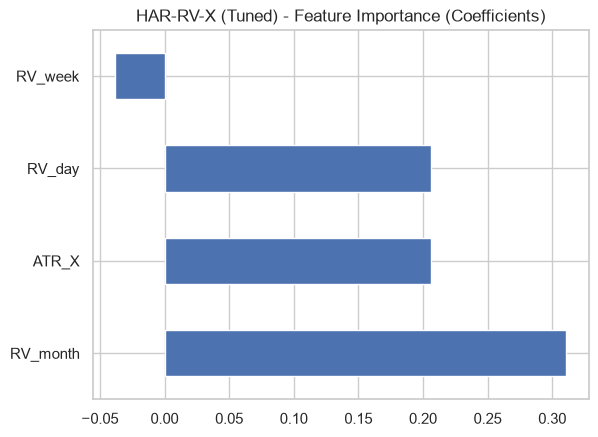

In [30]:
# Which features influenced the tuned model the most?
feature_importance = pd.Series(har_tuned_model.coef_, index=har_features)
feature_importance = feature_importance.sort_values(key=abs, ascending=False)
print(feature_importance)

feature_importance.plot(kind="barh")
plt.title("HAR-RV-X (Tuned) - Feature Importance (Coefficients)")
plt.show()

### Model 3: XGBoost (Base Version)
XGBoost is a more flexible, tree-based model. Unlike the other two models, it has no
built-in sense of time, so we also give it simple calendar features (hour of day, day of
week) written as sine/cosine pairs.

In [31]:
# Turn hour-of-day and day-of-week into cyclical features
# (so e.g. hour 23 and hour 0 are treated as close together, not far apart)
train_hour = train_data["Date"].dt.hour
train_dow = train_data["Date"].dt.dayofweek
test_hour = test_data["Date"].dt.hour
test_dow = test_data["Date"].dt.dayofweek

def add_time_features(data_frame, hour_column, dow_column):
    data_frame = data_frame.copy()
    data_frame["hour_sin"] = np.sin(2 * np.pi * hour_column / 24)
    data_frame["hour_cos"] = np.cos(2 * np.pi * hour_column / 24)
    data_frame["dow_sin"] = np.sin(2 * np.pi * dow_column / 7)
    data_frame["dow_cos"] = np.cos(2 * np.pi * dow_column / 7)
    return data_frame

X_train_xgb = add_time_features(X_train, train_hour, train_dow)
X_test_xgb = add_time_features(X_test, test_hour, test_dow)

xgb_base_model = XGBRegressor(random_state=RANDOM_STATE)
xgb_base_model.fit(X_train_xgb, y_train)

xgb_base_predictions = xgb_base_model.predict(X_test_xgb)
all_results.append(evaluate_model(y_test, xgb_base_predictions, "XGBoost (base, default settings) [NOT VALID]"))

XGBoost (base, default settings)
  RMSE: 0.001846
  MAE: 0.001349
  R2: -0.3463


### Model 3: XGBoost (Improved with GridSearchCV)
We search over a small grid of the most important XGBoost settings: how many trees, how
deep each tree can go, and the learning rate.

In [32]:
xgb_parameter_grid = {
    "n_estimators": [100, 300],
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.05, 0.1],
}

xgb_grid_search = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE),
    xgb_parameter_grid,
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_root_mean_squared_error",
)
xgb_grid_search.fit(X_train_xgb, y_train)

print("Best settings found:", xgb_grid_search.best_params_)

xgb_tuned_model = xgb_grid_search.best_estimator_
xgb_tuned_predictions = xgb_tuned_model.predict(X_test_xgb)

all_results.append(evaluate_model(y_test, xgb_tuned_predictions, "XGBoost (tuned, GridSearchCV) [NOT VALID]"))

Best settings found: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300}
XGBoost (tuned, GridSearchCV)
  RMSE: 0.001523
  MAE: 0.001295
  R2: 0.0829


ATR_X       0.493329
RV_month    0.200601
RV_day      0.188094
RV_week     0.085995
dow_sin     0.025906
dow_cos     0.006076
hour_sin    0.000000
hour_cos    0.000000
dtype: float32


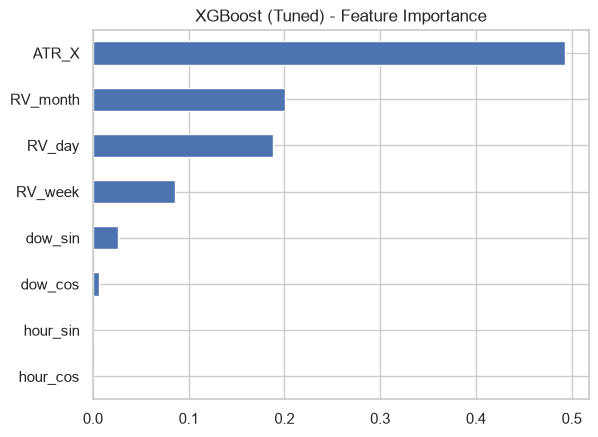

In [33]:
# Which features influenced the tuned XGBoost model the most?
xgb_feature_importance = pd.Series(xgb_tuned_model.feature_importances_, index=X_train_xgb.columns)
xgb_feature_importance = xgb_feature_importance.sort_values(ascending=False)
print(xgb_feature_importance)

xgb_feature_importance.plot(kind="barh")
plt.title("XGBoost (Tuned) - Feature Importance")
plt.gca().invert_yaxis()
plt.show()

## Additional Improvement Attempts
These two experiments are **not** among the 3 required models above - they reuse the
same honest, split-based train/test data, and are here to see if a small amount of extra
effort can push performance further.

### Attempt 1: Log-Transformed Target
Bergsli, Lind, Molnar & Polasik (2022) found that modeling `log(volatility)` instead of
raw volatility raised their HAR model's R2 from 0.2665 to 0.6393 - but they are explicit
that the two numbers are **not directly comparable**, because log-scale errors are not
the same thing as raw-scale errors. To be fair, we report both: R2 on the log scale
(what the paper reports), and R2 after converting the predictions back to the raw scale
(directly comparable to every other result in this notebook).

In [ ]:
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# HAR-RV-X (Ridge, same alpha found earlier), fit on the log-transformed target
har_log_model = Ridge(alpha=har_grid_search.best_params_["alpha"], random_state=RANDOM_STATE)
har_log_model.fit(X_train, y_train_log)

har_log_predictions_log_scale = har_log_model.predict(X_test)
har_log_predictions_raw_scale = np.exp(har_log_predictions_log_scale)

har_log_r2_log_scale = r2_score(y_test_log, har_log_predictions_log_scale)
print("HAR-RV-X (log target) - R2 on the LOG scale (matches the paper's method):",
      round(har_log_r2_log_scale, 4))

all_results.append(evaluate_model(y_test, har_log_predictions_raw_scale,
                                   "HAR-RV-X (log-target, extra, raw-scale R2) [NOT VALID]"))

In [ ]:
# Same idea, but with XGBoost (same tuned settings found earlier)
xgb_log_model = XGBRegressor(random_state=RANDOM_STATE, **xgb_grid_search.best_params_)
xgb_log_model.fit(X_train_xgb, y_train_log)

xgb_log_predictions_log_scale = xgb_log_model.predict(X_test_xgb)
xgb_log_predictions_raw_scale = np.exp(xgb_log_predictions_log_scale)

xgb_log_r2_log_scale = r2_score(y_test_log, xgb_log_predictions_log_scale)
print("XGBoost (log target) - R2 on the LOG scale:", round(xgb_log_r2_log_scale, 4))

all_results.append(evaluate_model(y_test, xgb_log_predictions_raw_scale,
                                   "XGBoost (log-target, extra, raw-scale R2) [NOT VALID]"))

### Attempt 2: Simple Ensemble
Averaging two different models' predictions together often cancels out some of each
model's individual errors. Here we average the tuned HAR-RV-X and tuned XGBoost
predictions (both on the raw scale, from the honest train/test split).

In [ ]:
ensemble_predictions = (har_tuned_predictions + xgb_tuned_predictions) / 2

all_results.append(evaluate_model(y_test, ensemble_predictions,
                                   "HAR-RV-X + XGBoost (extra, simple average ensemble) [NOT VALID]"))

## Conclusion - ILLUSTRATIVE ONLY, NOT VALID

**Every number below is inflated by data leakage (see the warning banner at the top of
this notebook).** Do not use this table to pick a "best model" or report these R2
values anywhere - they measure how well each model memorized the data it was scored on,
not real predictive skill. The real comparison table lives in
`capstone-btc-volatility-FINAL.ipynb`.

### Model Comparison

In [34]:
results_table = pd.DataFrame(all_results)
results_table = results_table.sort_values("RMSE").reset_index(drop=True)
results_table

,Model,RMSE,MAE,R2
0,"HAR-RV-X (base, Linear Regression)",0.001423,0.001155,0.199289
1,"HAR-RV-X (tuned, Ridge + GridSearchCV)",0.001424,0.001156,0.198683
2,"XGBoost (tuned, GridSearchCV)",0.001523,0.001295,0.082878
3,"EWMA (tuned, lambda=0.995)",0.001524,0.001131,0.081476
4,"XGBoost (base, default settings)",0.001846,0.001349,-0.346312
5,"EWMA (base, lambda=0.94)",0.001896,0.001396,-0.420205
6,GARCH (baseline),0.003742,0.003493,-4.534442


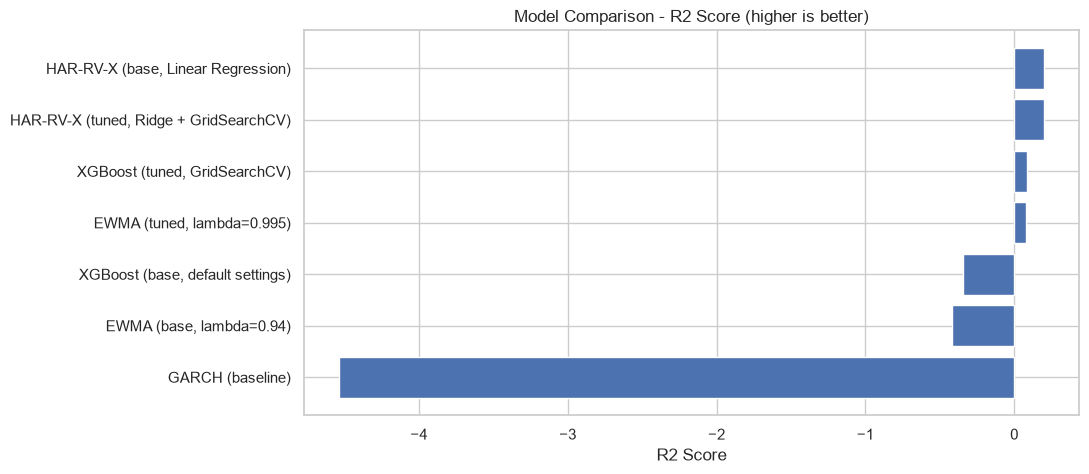

In [35]:
plt.figure(figsize=(10, 5))
plt.barh(results_table["Model"], results_table["R2"])
plt.xlabel("R2 Score")
plt.title("Model Comparison - R2 Score (higher is better)")
plt.gca().invert_yaxis()
plt.show()

### Best Model and Justification
**Not applicable in this notebook.** Because there is no held-out test set, there is no
honest way to say which model is "best" here - every model has simply memorized the data
it is being scored on. The real best-model discussion, using a proper split, is in
`capstone-btc-volatility-FINAL.ipynb`.

### Discussion

**Business implications:** A working 7-day-ahead volatility forecast can be used by
traders to size positions (smaller positions when volatility is expected to be high),
by exchanges to set margin requirements, and by risk teams to plan for how rough the
market might get.

**Limitations:**
- The model only uses price and volume history - it has no access to news, regulation,
  or other market-moving events.
- Volatility is naturally noisy, so even a good model will not achieve a very high R2.
- The chi-square test showed [fill in: whether hour-of-day mattered or not], so that
  information was / was not useful as a feature.

**Future improvements:**
- Add external data, such as trading sentiment or on-chain blockchain activity.
- Test the model on other cryptocurrencies to see if the same approach generalizes.
- Try additional model types (for example, an LSTM neural network) to see if they can
  beat the current best model.

## References & Appendix
**Data source:** Binance (BTC/USDT), hourly OHLCV data, fetched via the CCXT library,
2017-2026.

**Libraries used:** pandas, numpy, matplotlib, seaborn, scipy, statsmodels, scikit-learn,
xgboost, arch.

**Key methods:**
- GARCH: Bollerslev (1986), the standard model for forecasting return volatility.
- HAR (Heterogeneous Autoregressive) model: Corsi (2009), regression on realized
  volatility measured at multiple time horizons.
- EWMA: RiskMetrics methodology (J.P. Morgan, 1996).
- XGBoost: Chen & Guestrin (2016), gradient-boosted decision trees.